# Phase 7 — Model Explainability: Understanding NYC Property Prices

## Objective

A high-performing machine learning model is more useful when we can explain **why** it makes its predictions.

In this phase, we use **SHAP (SHapley Additive exPlanations)** to interpret the final XGBoost regression model developed in Phase 6.

### Business question

> **What factors most influence NYC property price predictions?**

SHAP will help us answer this at two levels:

- **Global explainability:** Which features are most important across the entire test set?
- **Local explainability:** Why did the model make a particular prediction for one property?

### Expected outputs

1. SHAP summary plot
2. SHAP feature-importance ranking
3. Feature-importance DataFrame
4. Individual-property SHAP explanation
5. SHAP waterfall plot
6. SHAP dependence plots
7. Portfolio-ready business insights

> **Important:** The model used for explainability should be the same final model selected in Phase 6. If your Phase 6 model uses a different preprocessing pipeline or hyperparameters, reproduce that exact pipeline here rather than training a different model.

## 1. Install and Import Libraries

We use:

- `pandas` and `numpy` for data preparation
- `matplotlib` for visualization
- `scikit-learn` for the train/test split
- `XGBoost` for the regression model
- `SHAP` for model explainability

In [1]:
# Install SHAP if it is not already available in the environment.
# In Google Colab, this cell can be run as-is.
!pip install -q shap

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Make plots easier to read in the notebook.
plt.rcParams["figure.figsize"] = (10, 6)

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


## 2. Load the Feature-Engineered Dataset

This notebook uses the feature-engineered Zillow dataset produced in the previous phase.

If your file is stored somewhere else, update `DATA_PATH` accordingly.

In [3]:
DATA_PATH = "/content/feature_engineered_zillow_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1892, 39)


,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,...,rental_yield_score,price_sqft_score,tax_assessment_ratio,tax_value_score,zip_median_price_x,zip_median_price_y,zip_median_price,location_score,investment_score,investment_rating
0,"572 Louisiana Avenue #1, Brooklyn, NY 11239",11239,2.0,2.0,1017.0,40.647620,-73.886810,250000.0,3550.0,856400.0,...,95.983087,93.763214,2.281176,85.517970,452000.0,452000.0,452000.0,11.284355,72.7,Good
1,"2183 Ocean Ave #4A, Brooklyn, NY 11229",11229,1.0,1.0,541.0,40.608430,-73.952736,485000.0,2489.0,473800.0,...,63.583510,9.566596,1.684536,80.443975,350000.0,350000.0,350000.0,4.889006,37.9,Below Average
2,"8885 15th Ave, Brooklyn, NY 11228",11228,4.0,3.0,2060.0,40.605550,-74.015200,1299000.0,5015.0,1315600.0,...,38.900634,29.651163,1.016166,62.156448,1280000.0,1280000.0,1280000.0,91.014799,53.1,Moderate
3,"300 Milford St, Brooklyn, NY 11208",11208,3.0,2.0,1232.0,40.671783,-73.876625,595000.0,3574.0,602800.0,...,73.572939,57.505285,1.225210,74.392178,809500.0,809500.0,809500.0,37.764271,60.7,Moderate
4,"2711 Avenue X Unit F2, Brooklyn, NY 11235",11235,2.0,1.0,1000.0,40.704254,-73.966420,345000.0,3056.0,350500.0,...,85.465116,84.645877,2.368116,86.310782,527000.0,527000.0,527000.0,13.662791,67.4,Good


In [4]:
# Review the available columns before selecting model features.
print("Available columns:")
print(df.columns.tolist())

Available columns:
['address', 'zip_code', 'bedrooms', 'bathrooms', 'living_area', 'latitude', 'longitude', 'listing_price', 'rent_estimate', 'zestimate', 'home_type', 'days_on_zillow', 'listing_status', 'zpid', 'tax_assessed_value', 'clean_address', 'property_key', 'zestimate_missing', 'tax_assessed_missing', 'price_per_sqft', 'price_outlier', 'price_vs_zestimate', 'price_zestimate_ratio', 'rent_missing', 'tax_missing', 'annual_rent', 'rental_yield', 'rental_yield_percent', 'property_size_category', 'rental_yield_score', 'price_sqft_score', 'tax_assessment_ratio', 'tax_value_score', 'zip_median_price_x', 'zip_median_price_y', 'zip_median_price', 'location_score', 'investment_score', 'investment_rating']


## 3. Define the Target and Model Features

### Target

The model predicts:

`listing_price`

### Features

The explainability model follows the Phase 6 feature set:

- `bedrooms`
- `bathrooms`
- `living_area`
- `latitude`
- `longitude`
- `zip_code`
- `home_type`
- `listing_status`
- `days_on_zillow`
- `rent_estimate`
- `tax_assessed_value`
- `zestimate`

Missing-value indicators are also created for the selected numeric variables.

### Features intentionally excluded

We do **not** use identifiers, addresses, or target-derived features such as:

- `zpid`
- `address`
- `clean_address`
- `price_per_sqft`
- `rental_yield`
- `investment_score`
- `price_vs_zestimate`
- `price_zestimate_ratio`
- `price_outlier`
- `property_key`

This helps prevent leakage and keeps the explainability analysis aligned with the modeling objective.

In [5]:
target = "listing_price"

base_features = [
    "bedrooms",
    "bathrooms",
    "living_area",
    "latitude",
    "longitude",
    "zip_code",
    "home_type",
    "listing_status",
    "days_on_zillow",
    "rent_estimate",
    "tax_assessed_value",
    "zestimate",
]

missing_indicator_features = [
    "bedrooms",
    "bathrooms",
    "living_area",
    "latitude",
    "longitude",
    "days_on_zillow",
    "rent_estimate",
    "tax_assessed_value",
    "zestimate",
]

required_columns = [target] + base_features
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing from the dataset: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


## 4. Prepare the Modeling Data

Rows without a valid target cannot be used for supervised learning, so they are removed.

We also create missing-value indicators **before imputation**. This preserves information about whether a value was originally missing.

In [6]:
# Keep only rows with a valid target.
model_df = df[required_columns].copy()
model_df[target] = pd.to_numeric(model_df[target], errors="coerce")

model_df = model_df.dropna(subset=[target]).reset_index(drop=True)

print(f"Rows available for modeling: {len(model_df):,}")

Rows available for modeling: 1,892


In [7]:
# Convert numeric columns to numeric dtype.
numeric_features = [
    "bedrooms",
    "bathrooms",
    "living_area",
    "latitude",
    "longitude",
    "zip_code",
    "days_on_zillow",
    "rent_estimate",
    "tax_assessed_value",
    "zestimate",
]

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Create missing-value indicators before filling missing values.
for col in missing_indicator_features:
    model_df[f"{col}_missing"] = model_df[col].isna().astype(int)

X = model_df.drop(columns=target).copy()
y = model_df[target].copy()

print(f"Feature matrix shape before encoding: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape before encoding: (1892, 21)
Target shape: (1892,)


## 5. Train/Test Split

We split the data before calculating imputation values.

This is important because using information from the test set to preprocess the training data can introduce **data leakage**.

The test set remains unseen until model evaluation and explainability.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

Training rows: 1,513
Testing rows:  379


## 6. Encode Categorical Variables

XGBoost requires numerical input.

`home_type` and `listing_status` are categorical, so we one-hot encode them.

We use `reindex` after encoding so that the training and test matrices contain exactly the same columns.

In [9]:
categorical_features = ["home_type", "listing_status"]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# Ensure train and test have identical feature columns.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Encoded training shape: {X_train.shape}")
print(f"Encoded testing shape:  {X_test.shape}")

Encoded training shape: (1513, 25)
Encoded testing shape:  (379, 25)


## 7. Handle Missing Values

For numeric variables, missing values are filled using the **training-set median**.

The same training medians are then applied to the test set.

This prevents information from the test set from influencing preprocessing.

In [10]:
numeric_model_columns = X_train.select_dtypes(include=np.number).columns

train_medians = X_train[numeric_model_columns].median()

X_train[numeric_model_columns] = X_train[numeric_model_columns].fillna(train_medians)
X_test[numeric_model_columns] = X_test[numeric_model_columns].fillna(train_medians)

# Handle any remaining missing values, including unexpected non-numeric values.
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Remaining missing values in X_train:", X_train.isna().sum().sum())
print("Remaining missing values in X_test:", X_test.isna().sum().sum())

Remaining missing values in X_train: 0
Remaining missing values in X_test: 0


## 8. Train the XGBoost Model

For this notebook, we reproduce the XGBoost approach used in Phase 6.

If you already saved your final Phase 6 model, replace this training cell with the model-loading code and use that exact model.

The goal of SHAP is to explain the model you actually selected—not a separate replacement model.

In [11]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## 9. Create the SHAP Explainer

Because XGBoost is a tree-based model, `shap.TreeExplainer` is an efficient choice for calculating SHAP values.

A SHAP value represents how much an individual feature contributes to moving a prediction away from the model's baseline prediction.

In [12]:
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set.
shap_values = explainer(X_test)

print(f"SHAP matrix shape: {shap_values.values.shape}")

SHAP matrix shape: (379, 25)


## 10. Global Explainability — What Affects NYC Property Prices?

The SHAP beeswarm plot shows:

- **Feature ranking:** features at the top have greater overall influence.
- **SHAP value:** values to the right increase the prediction; values to the left decrease it.
- **Color:** red generally represents higher feature values and blue lower feature values.

The direction of the relationship should be interpreted from the actual plot rather than assumed in advance.

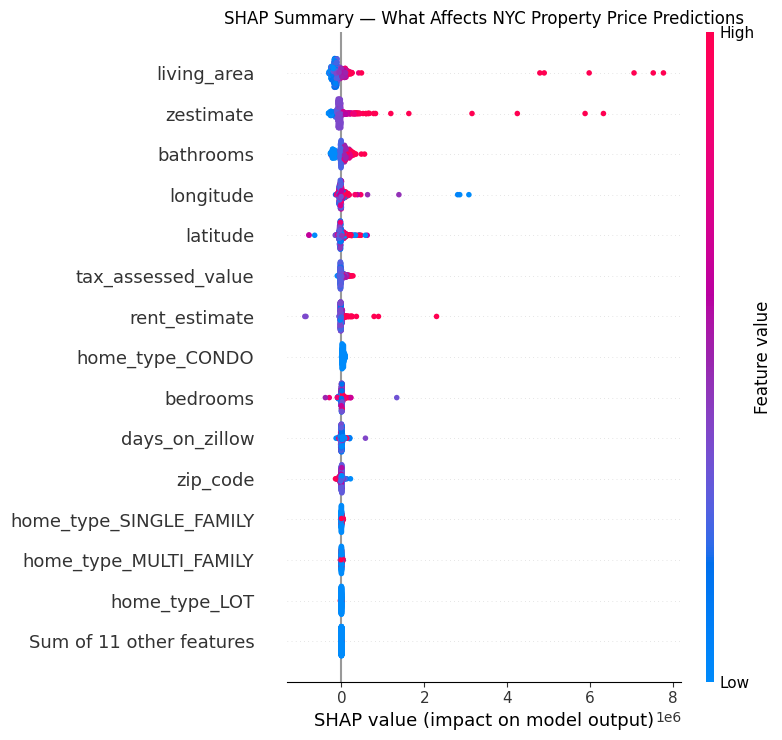

In [13]:
plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — What Affects NYC Property Price Predictions")
plt.tight_layout()
plt.show()

### How to read the SHAP summary plot

For example, if high `living_area` values appear mostly on the positive SHAP side, the model generally associates larger living areas with higher predicted prices.

If a feature's points appear on both sides, its effect may depend on the property's other characteristics or on nonlinear relationships learned by the model.

**Do not interpret SHAP as proof of causation.** SHAP explains the model's learned associations; it does not establish that changing a feature will cause a property price to change.

## 11. SHAP Feature Importance

A bar plot provides a simpler ranking of the most influential features.

The ranking is based on the **mean absolute SHAP value** across the test set.

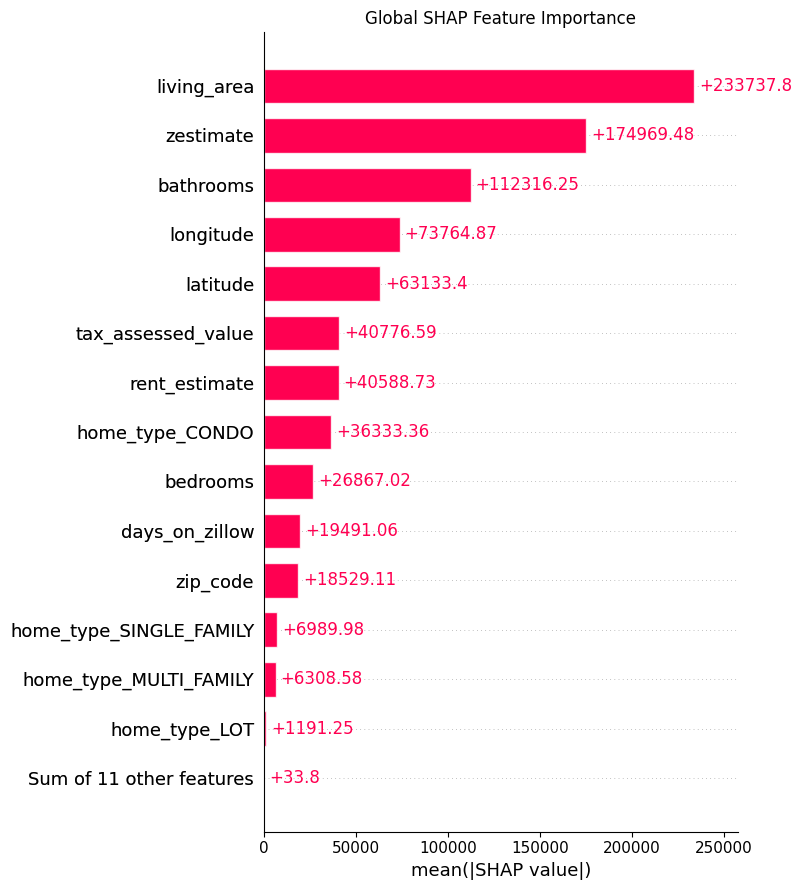

In [14]:
plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

## 12. Create a Feature-Importance Table

The table below converts SHAP values into a portfolio-friendly ranking.

Higher `mean_abs_shap` means the feature has a larger average impact on model predictions, regardless of whether the impact is positive or negative.

In [15]:
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

feature_importance.insert(
    0,
    "rank",
    np.arange(1, len(feature_importance) + 1)
)

feature_importance.head(15)

,rank,feature,mean_abs_shap
0,1,living_area,233737.796875
1,2,zestimate,174969.484375
2,3,bathrooms,112316.250000
3,4,longitude,73764.867188
4,5,latitude,63133.402344
5,6,tax_assessed_value,40776.589844
6,7,rent_estimate,40588.726562
7,8,home_type_CONDO,36333.363281
8,9,bedrooms,26867.017578
9,10,days_on_zillow,19491.058594


### Top 10 Most Influential Features

The actual ranking below is generated from the trained model. This is preferable to hard-coding an expected ranking because SHAP importance depends on the data and model.

In [16]:
top_features = feature_importance.head(10)

top_features

,rank,feature,mean_abs_shap
0,1,living_area,233737.796875
1,2,zestimate,174969.484375
2,3,bathrooms,112316.250000
3,4,longitude,73764.867188
4,5,latitude,63133.402344
5,6,tax_assessed_value,40776.589844
6,7,rent_estimate,40588.726562
7,8,home_type_CONDO,36333.363281
8,9,bedrooms,26867.017578
9,10,days_on_zillow,19491.058594


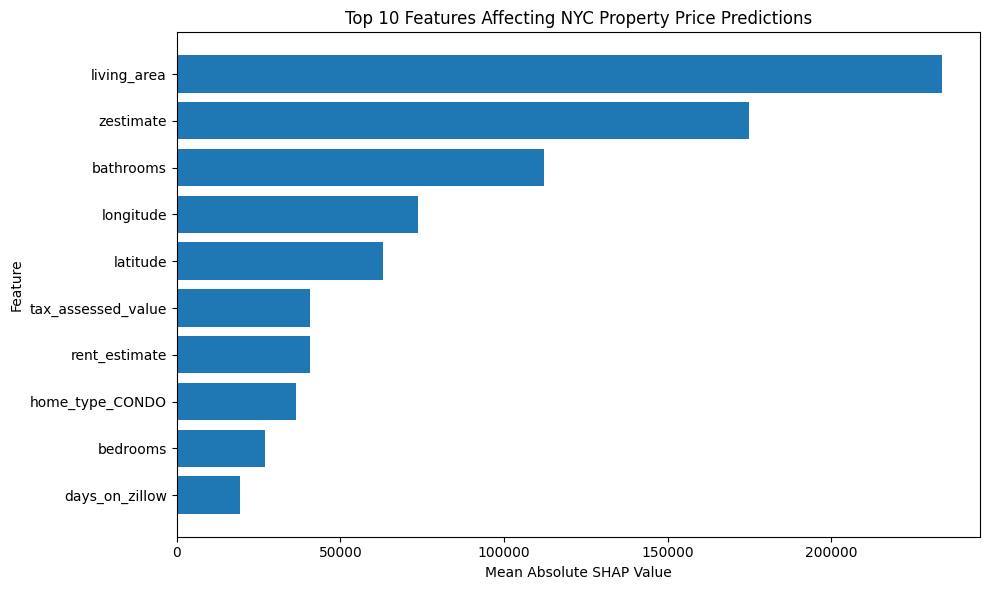

In [17]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["mean_abs_shap"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Features Affecting NYC Property Price Predictions")

plt.tight_layout()
plt.show()

## 13. Local Explainability — Explain One Property

Global importance tells us what matters overall. Local explainability tells us:

> **Why did the model make this specific prediction?**

We select one property from the test set and inspect its prediction and feature contributions.

In [18]:
property_index = 0

property_data = X_test.iloc[[property_index]]
actual_price = y_test.iloc[property_index]
predicted_price = model.predict(property_data)[0]

print(f"Actual listing price:    ${actual_price:,.0f}")
print(f"Predicted listing price: ${predicted_price:,.0f}")
print(f"Prediction error:        ${predicted_price - actual_price:,.0f}")

property_data

Actual listing price:    $799,000
Predicted listing price: $944,386
Prediction error:        $145,386


,bedrooms,bathrooms,living_area,latitude,longitude,zip_code,days_on_zillow,rent_estimate,tax_assessed_value,zestimate,...,days_on_zillow_missing,rent_estimate_missing,tax_assessed_value_missing,zestimate_missing,home_type_CONDO,home_type_LOT,home_type_MANUFACTURED,home_type_MULTI_FAMILY,home_type_SINGLE_FAMILY,home_type_TOWNHOUSE
892,3.0,3.0,1400.0,40.579403,-73.96372,11235,2,4104.0,642700.0,856400.0,...,0,0,0,0,0,0,0,0,0,0


## 14. Property-Level SHAP Contributions

Positive SHAP values push the prediction **higher** than the baseline.

Negative SHAP values push the prediction **lower** than the baseline.

The table below identifies the largest contributors for the selected property.

In [19]:
property_explanation = pd.DataFrame({
    "feature": X_test.columns,
    "feature_value": X_test.iloc[property_index].values,
    "shap_value": shap_values.values[property_index]
})

property_explanation["abs_shap"] = property_explanation["shap_value"].abs()

property_explanation = property_explanation.sort_values(
    "abs_shap",
    ascending=False
).reset_index(drop=True)

property_explanation.head(10)

,feature,feature_value,shap_value,abs_shap
0,living_area,1400.000000,-217103.343750,217103.343750
1,bathrooms,3.000000,96739.593750,96739.593750
2,days_on_zillow,2.000000,58858.804688,58858.804688
3,zestimate,856400.000000,-51595.984375,51595.984375
4,latitude,40.579403,36503.804688,36503.804688
5,home_type_CONDO,0.000000,16334.349609,16334.349609
6,tax_assessed_value,642700.000000,-13963.279297,13963.279297
7,longitude,-73.963720,10574.006836,10574.006836
8,bedrooms,3.000000,-9037.439453,9037.439453
9,rent_estimate,4104.000000,6904.994629,6904.994629


## 15. SHAP Waterfall Plot

The waterfall plot provides a visual explanation of one prediction.

It starts from the model's expected value and shows how individual features move the prediction up or down until the final predicted price.

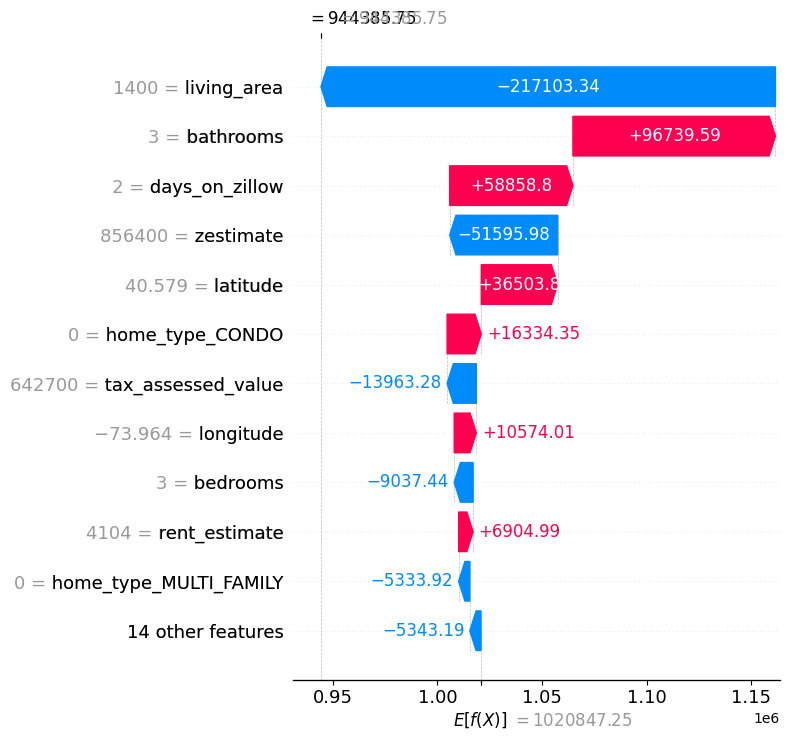

In [20]:
shap.plots.waterfall(
    shap_values[property_index],
    max_display=12,
    show=False
)

plt.tight_layout()
plt.show()

## 16. Positive and Negative Contributors

For the selected property, we can separately inspect features that increased and decreased the prediction.

In [21]:
positive_features = property_explanation[
    property_explanation["shap_value"] > 0
].head(10)

negative_features = property_explanation[
    property_explanation["shap_value"] < 0
].head(10)

print("Top positive contributors:")
display(positive_features)

print("Top negative contributors:")
display(negative_features)

Top positive contributors:


,feature,feature_value,shap_value,abs_shap
1,bathrooms,3.000000,96739.593750,96739.593750
2,days_on_zillow,2.000000,58858.804688,58858.804688
4,latitude,40.579403,36503.804688,36503.804688
5,home_type_CONDO,0.000000,16334.349609,16334.349609
7,longitude,-73.963720,10574.006836,10574.006836
9,rent_estimate,4104.000000,6904.994629,6904.994629
13,home_type_LOT,0.000000,26.601635,26.601635


Top negative contributors:


,feature,feature_value,shap_value,abs_shap
0,living_area,1400.0,-217103.343750,217103.343750
3,zestimate,856400.0,-51595.984375,51595.984375
6,tax_assessed_value,642700.0,-13963.279297,13963.279297
8,bedrooms,3.0,-9037.439453,9037.439453
10,home_type_MULTI_FAMILY,0.0,-5333.916504,5333.916504
11,zip_code,11235.0,-4765.500000,4765.500000
12,home_type_SINGLE_FAMILY,0.0,-586.636963,586.636963
14,home_type_MANUFACTURED,0.0,-9.802900,9.802900
15,home_type_TOWNHOUSE,0.0,-7.733831,7.733831


## 17. Feature Dependence Analysis

Dependence plots help us investigate how a feature's values relate to its SHAP contribution.

We examine:

- `living_area`
- `zestimate`
- `bathrooms`

These plots can reveal nonlinear relationships that a simple linear model may not capture.

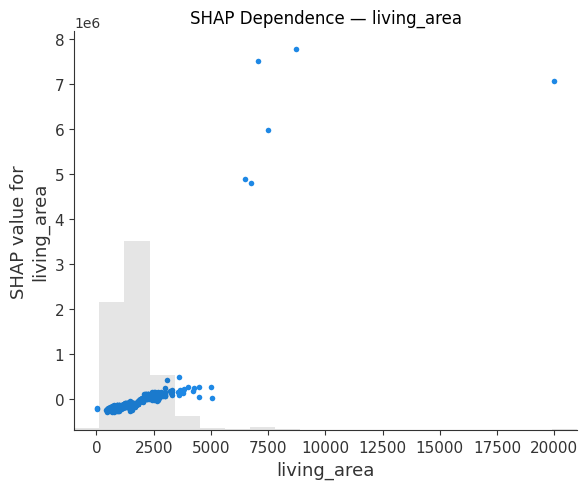

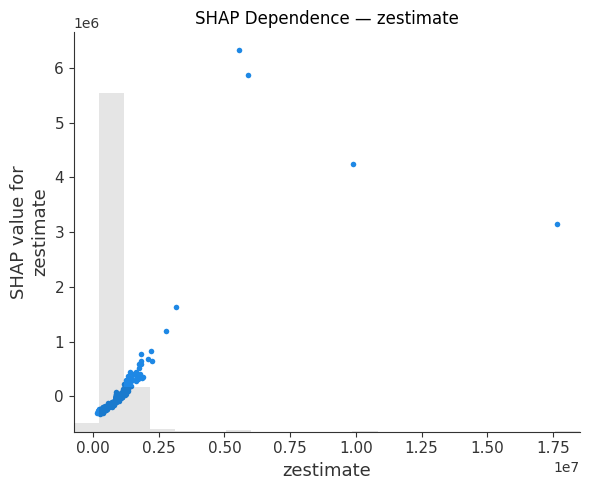

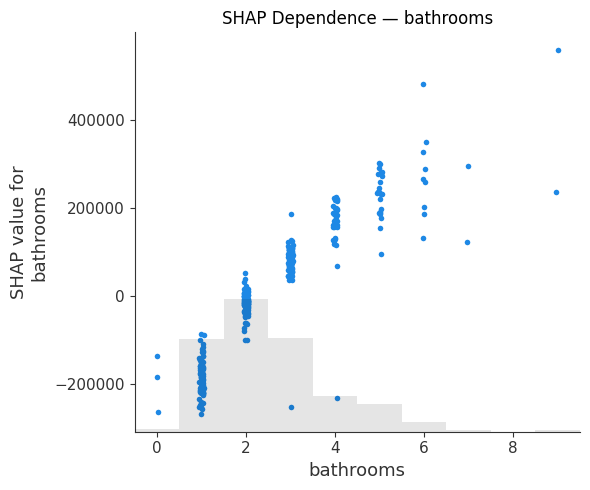

In [22]:
for feature in ["living_area", "zestimate", "bathrooms"]:
    if feature in X_test.columns:
        shap.plots.scatter(
            shap_values[:, feature],
            show=False
        )
        plt.title(f"SHAP Dependence — {feature}")
        plt.tight_layout()
        plt.show()

## 18. Location Features

NYC property prices are strongly location-dependent, so `latitude`, `longitude`, and `zip_code` can be important model features.

However, these features should not be interpreted as simple causal relationships.

A better business interpretation is:

> **Geographic features capture location-specific differences in NYC property prices.**

SHAP can show how much location-related information contributes to the model, but it does not mean that changing a property's latitude or longitude would cause its price to change.

## 19. Save SHAP Results for the Portfolio

Saving the feature-importance table makes the analysis reproducible and allows the results to be reused in a dashboard or README.

In [23]:
# Create output directories if they do not already exist.
os.makedirs("../data", exist_ok=True)
os.makedirs("../images", exist_ok=True)

# Save feature-importance results.
feature_importance.to_csv(
    "../data/shap_feature_importance.csv",
    index=False
)

print("Saved: ../data/shap_feature_importance.csv")

Saved: ../data/shap_feature_importance.csv


In [24]:
# Save the SHAP beeswarm plot.
plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — NYC Property Price Model")
plt.tight_layout()

plt.savefig(
    "../images/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Save the SHAP bar plot.
plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Feature Importance — NYC Property Price Model")
plt.tight_layout()

plt.savefig(
    "../images/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Saved SHAP visualizations to ../images/")

Saved SHAP visualizations to ../images/


# 20. Key Findings

The SHAP analysis provides an interpretable view of the NYC property-price model.

### Global insights

The feature-importance table identifies which variables have the greatest average influence on predictions. In this project, important candidates include property size, valuation estimates, location, and property characteristics—but the **actual ranking should be taken directly from the SHAP results generated above**.

### Local insights

The waterfall plot explains why the model predicts a particular price for an individual property by showing which features push the prediction above or below the model's baseline.

### Business interpretation

This analysis can help answer questions such as:

- Which property characteristics are most associated with higher predicted prices?
- How much does location-related information influence predictions?
- Which features explain unusually high or low predictions?
- Why did the model value one property differently from another?

### Important limitation

SHAP explains the behavior of the trained model. It does **not** prove causation. A feature with high SHAP importance is influential to the model's predictions, but that does not mean the feature itself causes the observed price.

---

## Conclusion

SHAP transforms the NYC Real Estate Price Prediction model from a black box into an interpretable system.

By combining **global feature importance**, **direction of impact**, **individual prediction explanations**, and **dependence analysis**, we can connect model predictions to meaningful real-estate insights.

> **Final question answered:** *What affects NYC property price predictions?*

The answer is determined empirically from the model's SHAP values rather than assumed in advance.